In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数，加载数据
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import shap
import pickle
import json
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

Path('figures/feature_importance').mkdir(parents=True, exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 12
sss  = 9
ssss = 6

matplotlib.rcParams['figure.figsize']       = (3.2, 2.8)
matplotlib.rcParams['figure.dpi']           = 600
matplotlib.rcParams['font.sans-serif']      = ['Arial']
matplotlib.rcParams['font.family']          = 'sans-serif'
matplotlib.rcParams['font.style']           = 'normal'
matplotlib.rcParams['font.weight']          = 'bold'
matplotlib.rcParams["axes.labelweight"]     = "bold"
matplotlib.rcParams['axes.titlesize']       = sss
matplotlib.rcParams['legend.fontsize']      = ss
matplotlib.rcParams['axes.labelsize']       = ss
matplotlib.rcParams['xtick.labelsize']      = ss
matplotlib.rcParams['ytick.labelsize']      = ss
matplotlib.rcParams['axes.linewidth']       = 0.6
matplotlib.rcParams['lines.linewidth']      = 1.0
matplotlib.rcParams['axes.grid']            = False

# 加载特征列表
with open('data/cv_setup.pkl', 'rb') as f:
    cv_setup = pickle.load(f)
feature_cols = cv_setup['feature_cols']

# 加载原始数据集
df = pd.read_csv('data/full_dataset.csv')
X  = df[feature_cols].values

# 加载采样索引与RF scaler
sample_indices  = np.load('results/feature_importance/sample_indices_large.npy')
X_sample        = X[sample_indices]

with open('models/rf/rf_final_model.pkl', 'rb') as f:
    rf_package = pickle.load(f)
scaler_rf       = rf_package['scaler']
X_sample_scaled = scaler_rf.transform(X_sample)

# 加载XGB scaler
with open('models/xgboost/xgboost_final_model.pkl', 'rb') as f:
    xgb_package = pickle.load(f)
scaler_xgb          = xgb_package['scaler']
X_sample_scaled_xgb = scaler_xgb.transform(X_sample)

# 加载SHAP值
shap_values_rf  = np.load('results/feature_importance/shap_values_rf.npy')
shap_values_xgb = np.load('results/feature_importance/shap_values_xgb.npy')

try:
    shap_values_ridge = np.load('results/feature_importance/shap_values_ridge.npy')
    has_ridge_shap    = True
except FileNotFoundError:
    has_ridge_shap    = False

# 加载SHAP重要性统计
df_shap_rf  = pd.read_csv('results/feature_importance/shap_importance_rf.csv')
df_shap_xgb = pd.read_csv('results/feature_importance/shap_importance_xgb.csv')

# 加载Permutation和原生重要性
with open('results/feature_importance/perm_importance_all.json', 'r') as f:
    perm_importance_results = json.load(f)

with open('results/feature_importance/native_importance_all.json', 'r') as f:
    native_importance = json.load(f)

df_rf_native  = pd.read_csv('results/feature_importance/native_importance_rf.csv')
df_xgb_native = pd.read_csv('results/feature_importance/native_importance_xgb.csv')




In [2]:
# =============================================================================
# 整合各方法重要性，计算排名（归一化前），再归一化
# =============================================================================

# 按feature_cols顺序构建，index为整数（0,1,2...）
importance_comparison = pd.DataFrame({'Feature': feature_cols})

importance_comparison = importance_comparison.merge(
    df_rf_native[['feature', 'importance']].rename(
        columns={'feature': 'Feature', 'importance': 'RF_native'}),
    on='Feature', how='left'
)
importance_comparison = importance_comparison.merge(
    df_xgb_native[['feature', 'importance_gain']].rename(
        columns={'feature': 'Feature', 'importance_gain': 'XGB_native'}),
    on='Feature', how='left'
)
importance_comparison = importance_comparison.merge(
    df_shap_rf[['feature', 'importance_mean']].rename(
        columns={'feature': 'Feature', 'importance_mean': 'RF_SHAP'}),
    on='Feature', how='left'
)
importance_comparison = importance_comparison.merge(
    df_shap_xgb[['feature', 'importance_mean']].rename(
        columns={'feature': 'Feature', 'importance_mean': 'XGB_SHAP'}),
    on='Feature', how='left'
)
if has_ridge_shap:
    df_shap_ridge = pd.read_csv('results/feature_importance/shap_importance_ridge.csv')
    importance_comparison = importance_comparison.merge(
        df_shap_ridge[['feature', 'importance_mean']].rename(
            columns={'feature': 'Feature', 'importance_mean': 'Ridge_SHAP'}),
        on='Feature', how='left'
    )
for model_name in perm_importance_results.keys():
    perm_df = pd.DataFrame({
        'Feature':             feature_cols,
        f'{model_name}_Perm': perm_importance_results[model_name]['importances_mean']
    })
    importance_comparison = importance_comparison.merge(perm_df, on='Feature', how='left')

importance_cols = [col for col in importance_comparison.columns if col != 'Feature']

# 步骤1：归一化前计算排名（index为整数且顺序与feature_cols一致，无对齐问题）
rank_data = pd.DataFrame({'Feature': feature_cols})
for col in importance_cols:
    rank_data[f'{col}_rank'] = importance_comparison[col].rank(ascending=False)

rank_cols = [c for c in rank_data.columns if c.endswith('_rank')]
rank_data['Mean_Rank'] = rank_data[rank_cols].mean(axis=1)
rank_data['Std_Rank']  = rank_data[rank_cols].std(axis=1)
rank_data = rank_data.sort_values('Mean_Rank', ascending=True).reset_index(drop=True)

# 步骤2：归一化到0-1
for col in importance_cols:
    max_val = importance_comparison[col].max()
    if max_val > 0:
        importance_comparison[col] = importance_comparison[col] / max_val

importance_comparison['Mean_Importance'] = importance_comparison[importance_cols].mean(axis=1)
importance_comparison = importance_comparison.sort_values(
    'Mean_Importance', ascending=False).reset_index(drop=True)

importance_comparison.to_csv('results/feature_importance/importance_comparison.csv', index=False)




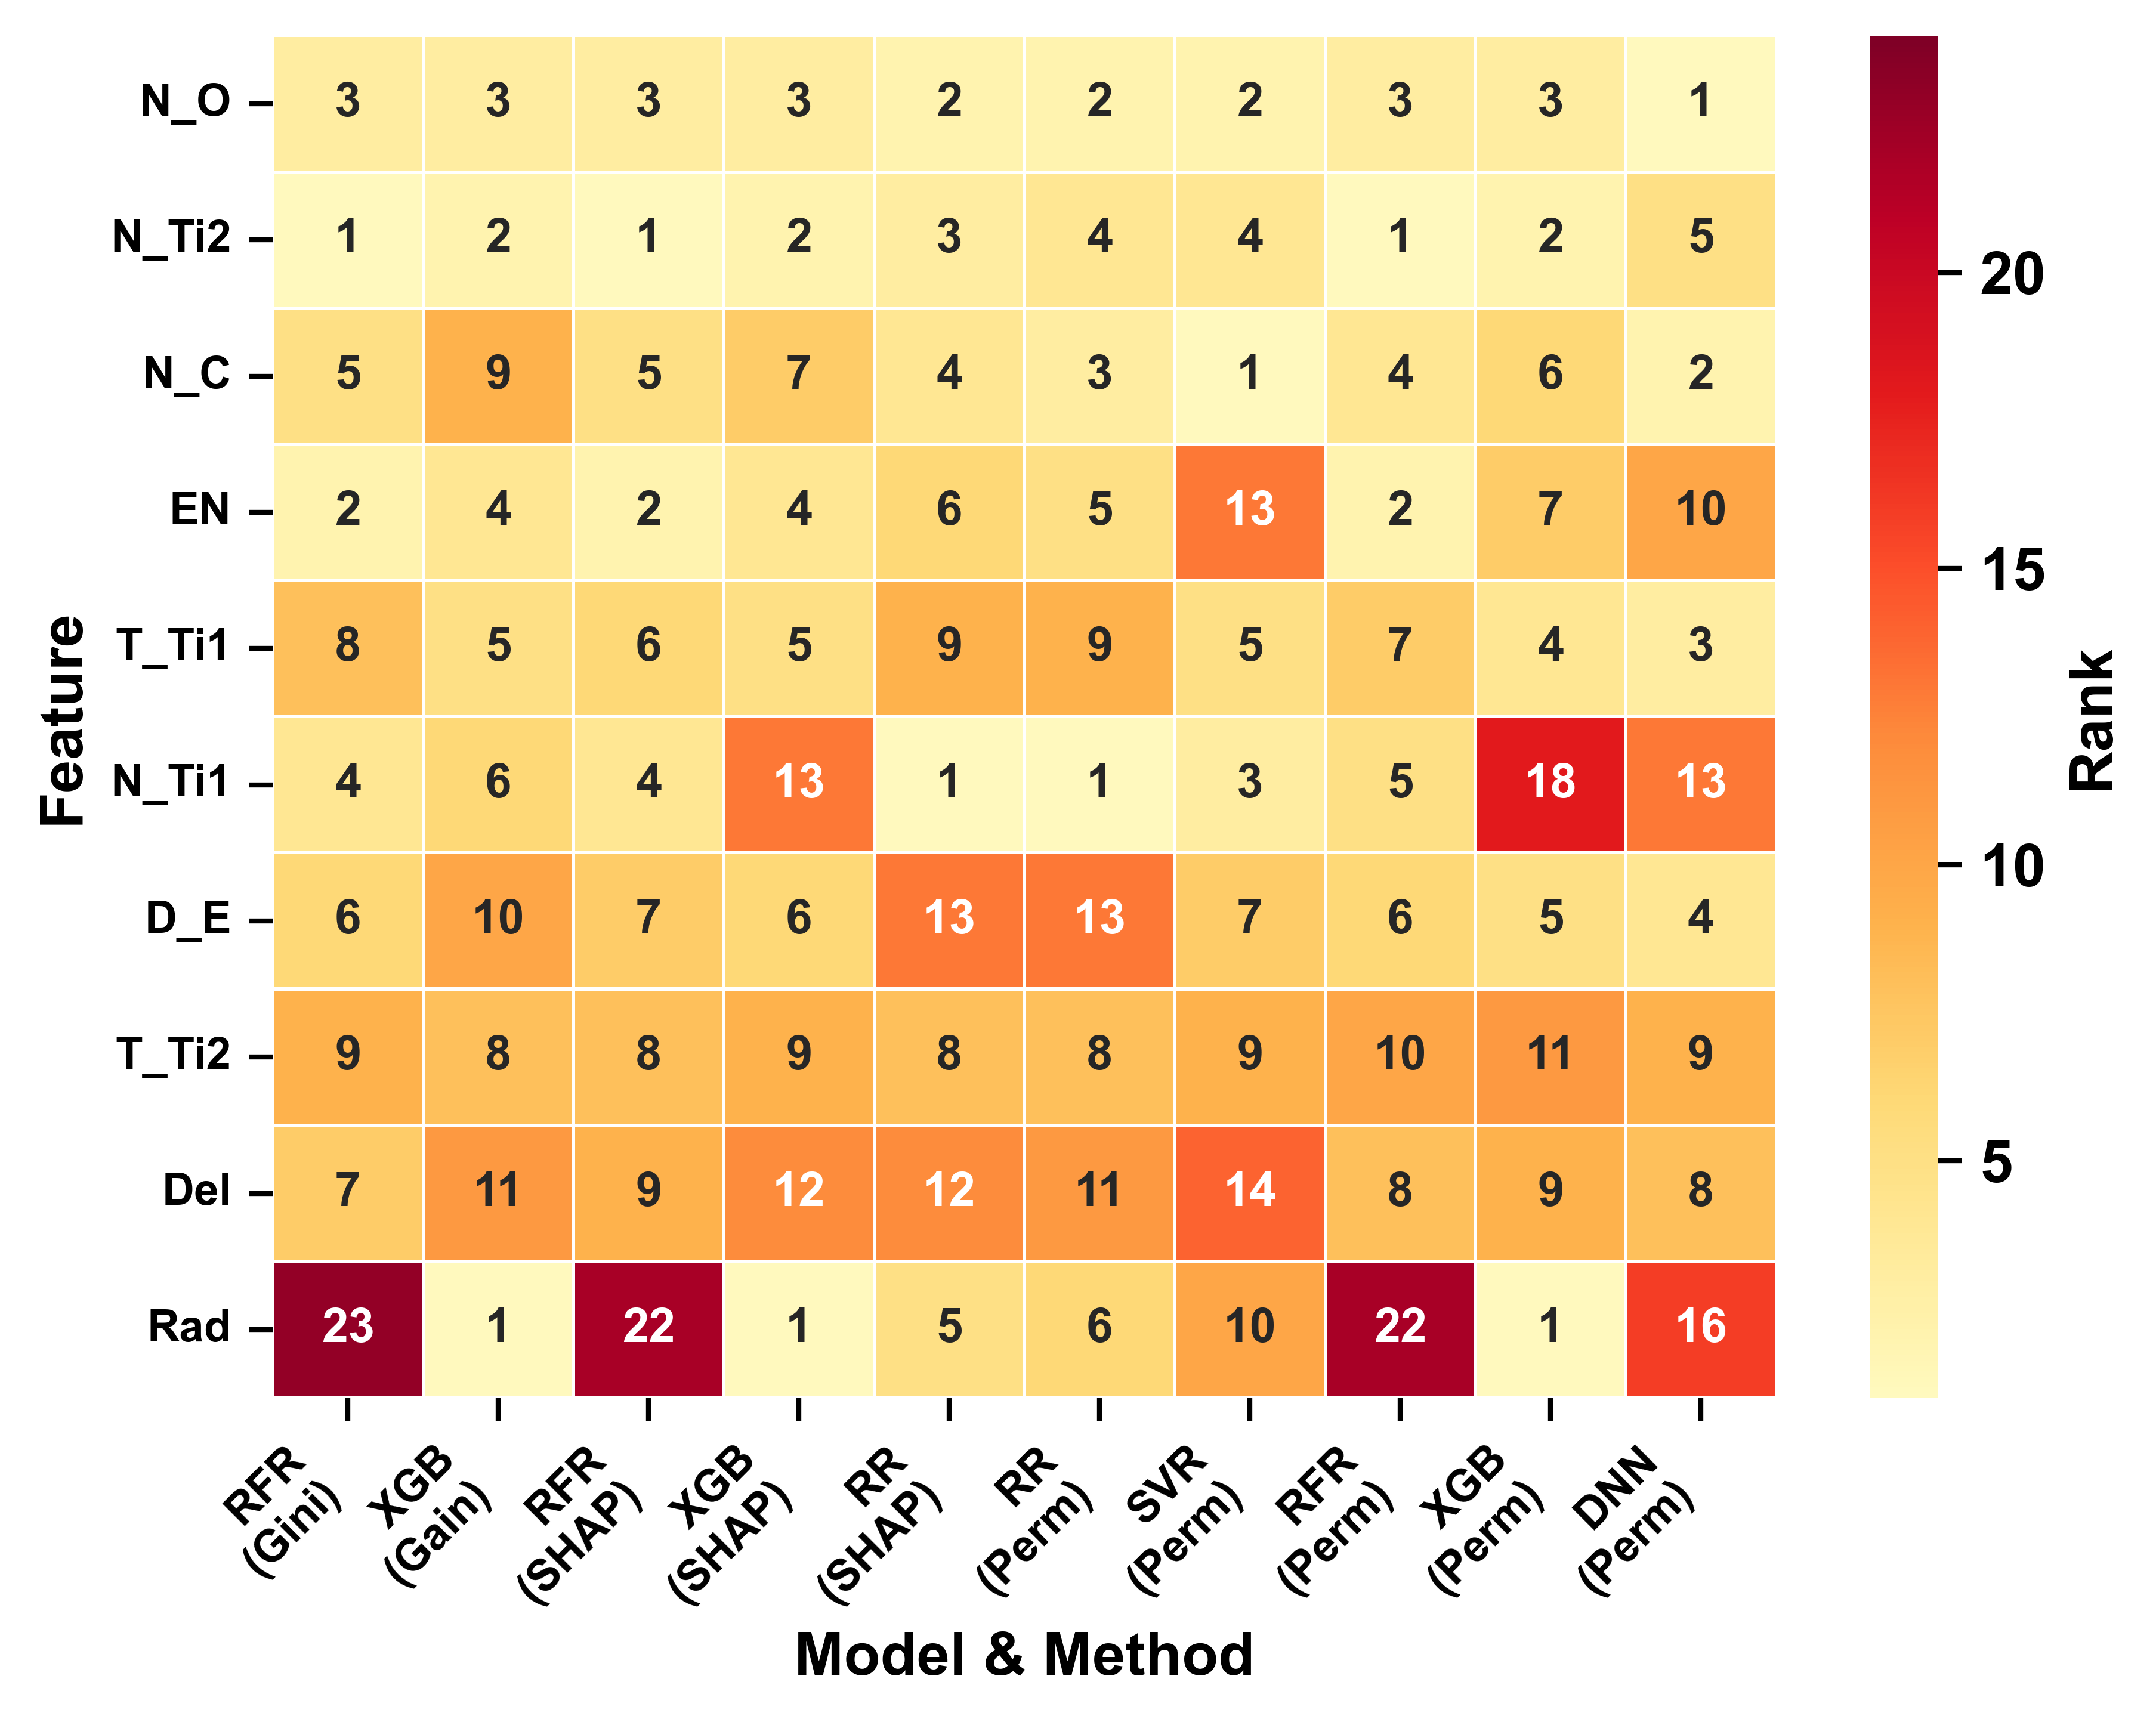

In [3]:
# =============================================================================
# 跨模型特征重要性热图（基于排名，Top 10）
# =============================================================================

top10_features = rank_data.head(10)['Feature'].tolist()
rank_matrix    = rank_data[rank_data['Feature'].isin(top10_features)].set_index('Feature')[rank_cols]

rename_dict = {
    'RF_native_rank':  'RFR\n(Gini)',
    'XGB_native_rank': 'XGB\n(Gain)',
    'RF_SHAP_rank':    'RFR\n(SHAP)',
    'XGB_SHAP_rank':   'XGB\n(SHAP)',
    'Ridge_SHAP_rank': 'RR\n(SHAP)',
    'Ridge_Perm_rank': 'RR\n(Perm)',
    'SVR_Perm_rank':   'SVR\n(Perm)',
    'RF_Perm_rank':    'RFR\n(Perm)',
    'XGB_Perm_rank':   'XGB\n(Perm)',
    'DNN_Perm_rank':   'DNN\n(Perm)'
}
rank_matrix = rank_matrix.rename(columns=rename_dict)

fig, ax = plt.subplots(figsize=(6.2, 4.9))

sns.heatmap(
    rank_matrix,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Rank'},
    linewidths=0.5,
    linecolor='white',
    vmin=1,
    vmax=len(feature_cols),
    center=len(feature_cols) // 2,
    ax=ax
)

ax.set_xlabel('Model & Method', fontsize=ss, weight='bold')
ax.set_ylabel('Feature',        fontsize=ss, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=sss, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=sss, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figures/feature_importance/importance_heatmap_rank.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/feature_importance/importance_heatmap_rank.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/feature_importance/importance_heatmap_rank.tif', dpi=600, bbox_inches='tight')
plt.show()




In [5]:

# =============================================================================
# 特征平均排名与标准差
# =============================================================================

print(f"{'Feature':<15s}  Mean Rank ± Std")
print("-" * 35)
for _, row in rank_data.iterrows():
    print(f"{row['Feature']:<15s}: 平均排名 {row['Mean_Rank']:.1f} ± {row['Std_Rank']:.1f}")
    
    

df_rank_output = rank_data[['Feature', 'Mean_Rank', 'Std_Rank']].copy()
df_rank_output.columns = ['Feature', 'Mean Rank', 'Std']
df_rank_output.to_excel('results/feature_importance/feature_rank_summary.xlsx', index=False)

Feature          Mean Rank ± Std
-----------------------------------
N_O            : 平均排名 2.5 ± 0.7
N_Ti2          : 平均排名 2.5 ± 1.4
N_C            : 平均排名 4.6 ± 2.4
EN             : 平均排名 5.5 ± 3.7
T_Ti1          : 平均排名 6.1 ± 2.1
N_Ti1          : 平均排名 6.8 ± 5.8
D_E            : 平均排名 7.7 ± 3.2
T_Ti2          : 平均排名 8.9 ± 1.0
Del            : 平均排名 10.1 ± 2.2
Rad            : 平均排名 10.7 ± 9.3
H_A            : 平均排名 11.6 ± 2.8
D_C            : 平均排名 13.2 ± 3.2
T_C            : 平均排名 13.6 ± 6.0
M_Inf          : 平均排名 13.9 ± 3.7
D_M2           : 平均排名 14.3 ± 4.0
D_M1           : 平均排名 15.0 ± 2.6
H_P            : 平均排名 16.0 ± 1.2
T_O            : 平均排名 16.6 ± 7.2
AR             : 平均排名 16.9 ± 4.2
H_Dens         : 平均排名 17.6 ± 2.1
Layer          : 平均排名 20.6 ± 2.2
SC_b           : 平均排名 21.1 ± 1.7
SC_a           : 平均排名 21.4 ± 1.4
Sides          : 平均排名 22.6 ± 1.6
